# Day 18 — UNICEF Data Day
### #30DayChartChallenge | April 2026

**The Toxic Truth.** Roughly 1 in 3 children worldwide — about 800 million — have blood lead levels at or above 5 µg/dL, the threshold for cognitive damage. India alone accounts for 275 million of them, more than a third of the global total.

**Data:** UNICEF & Pure Earth — [*The Toxic Truth: Children’s Exposure to Lead Pollution*](https://www.unicef.org/reports/toxic-truth-childrens-exposure-to-lead-pollution-2020) (2020), Annex (IHME GBD 2017 estimates)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(scales)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: UNICEF/Pure Earth Toxic Truth (2020), Annex — IHME GBD 2017 estimates
# Number of children (0–19) with blood lead level (BLL) > 5 µg/dL per country

df <- read.csv("../../data/day_18/lead_exposure_children.csv",
               stringsAsFactors = FALSE) %>%
  mutate(country = ifelse(country == "Iran (Islamic Republic of)", "Iran", country),
         country = ifelse(country == "Democratic Republic of the Congo", "DR Congo", country),
         children_m = children_bll_5_above / 1e6)

total <- sum(df$children_bll_5_above) / 1e6
india_val <- df$children_m[df$country == "India"]
india_share <- india_val / total * 100

top20 <- df %>%
  arrange(desc(children_m)) %>%
  slice_head(n = 20) %>%
  mutate(country = factor(country, levels = rev(country)),
         is_india = country == "India")

cat("Countries with data:", nrow(df), "\n")
cat("Global total: ~", round(total), "million children with BLL > 5 µg/dL\n")
cat("India:", round(india_val), "million (", round(india_share, 1),
    "% of global total)\n")
cat("Top 20 countries cover:", round(sum(top20$children_m)/total*100, 1),
    "% of the global total\n")

Countries with data: 168 


Global total: ~ 819 million children with BLL > 5 µg/dL


India: 276 million ( 33.7 % of global total)


Top 20 countries cover: 78.1 % of the global total


In [4]:
# — choropleth map: prep -----------------------------------------------------
# Same dataset, drawn as a world map for geographic intuition.

library(sf)
library(rnaturalearth)
library(countrycode)

world <- ne_countries(scale = "medium", returnclass = "sf") %>%
  filter(admin != "Antarctica")

df_iso <- df %>%
  mutate(iso3 = suppressWarnings(countrycode(country,
                                              origin = "country.name",
                                              destination = "iso3c"))) %>%
  filter(!is.na(iso3))

map_df <- world %>%
  left_join(df_iso, by = c("iso_a3" = "iso3")) %>%
  mutate(bin = cut(children_bll_5_above,
                   breaks = c(-Inf, 1e5, 1e6, 1e7, 5e7, Inf),
                   labels = c("<100K", "100K\u20131M", "1M\u201310M",
                              "10M\u201350M", ">50M")))

cat("Countries on map:", nrow(map_df), "\n")
cat("Matched with data:", sum(!is.na(map_df$bin)), "\n")
cat("No data:", sum(is.na(map_df$bin)), "\n")
cat("\nDistribution across bins:\n")
print(table(map_df$bin, useNA = "ifany"))

Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE



Warning message:
"package 'rnaturalearth' was built under R version 4.5.3"


Warning message:
"package 'countrycode' was built under R version 4.5.3"


Countries on map: 241 


Matched with data: 164 


No data: 77 



Distribution across bins:



  <100K 100K–1M  1M–10M 10M–50M    >50M    <NA> 
     47      53      49      14       1      77 


Warning message:
"st_centroid assumes attributes are constant over geometries"


Warning message in annotate("label", x = india_xy[1] + 4500000, y = india_xy[2] - :
"Ignoring unknown parameters: `label.size`"


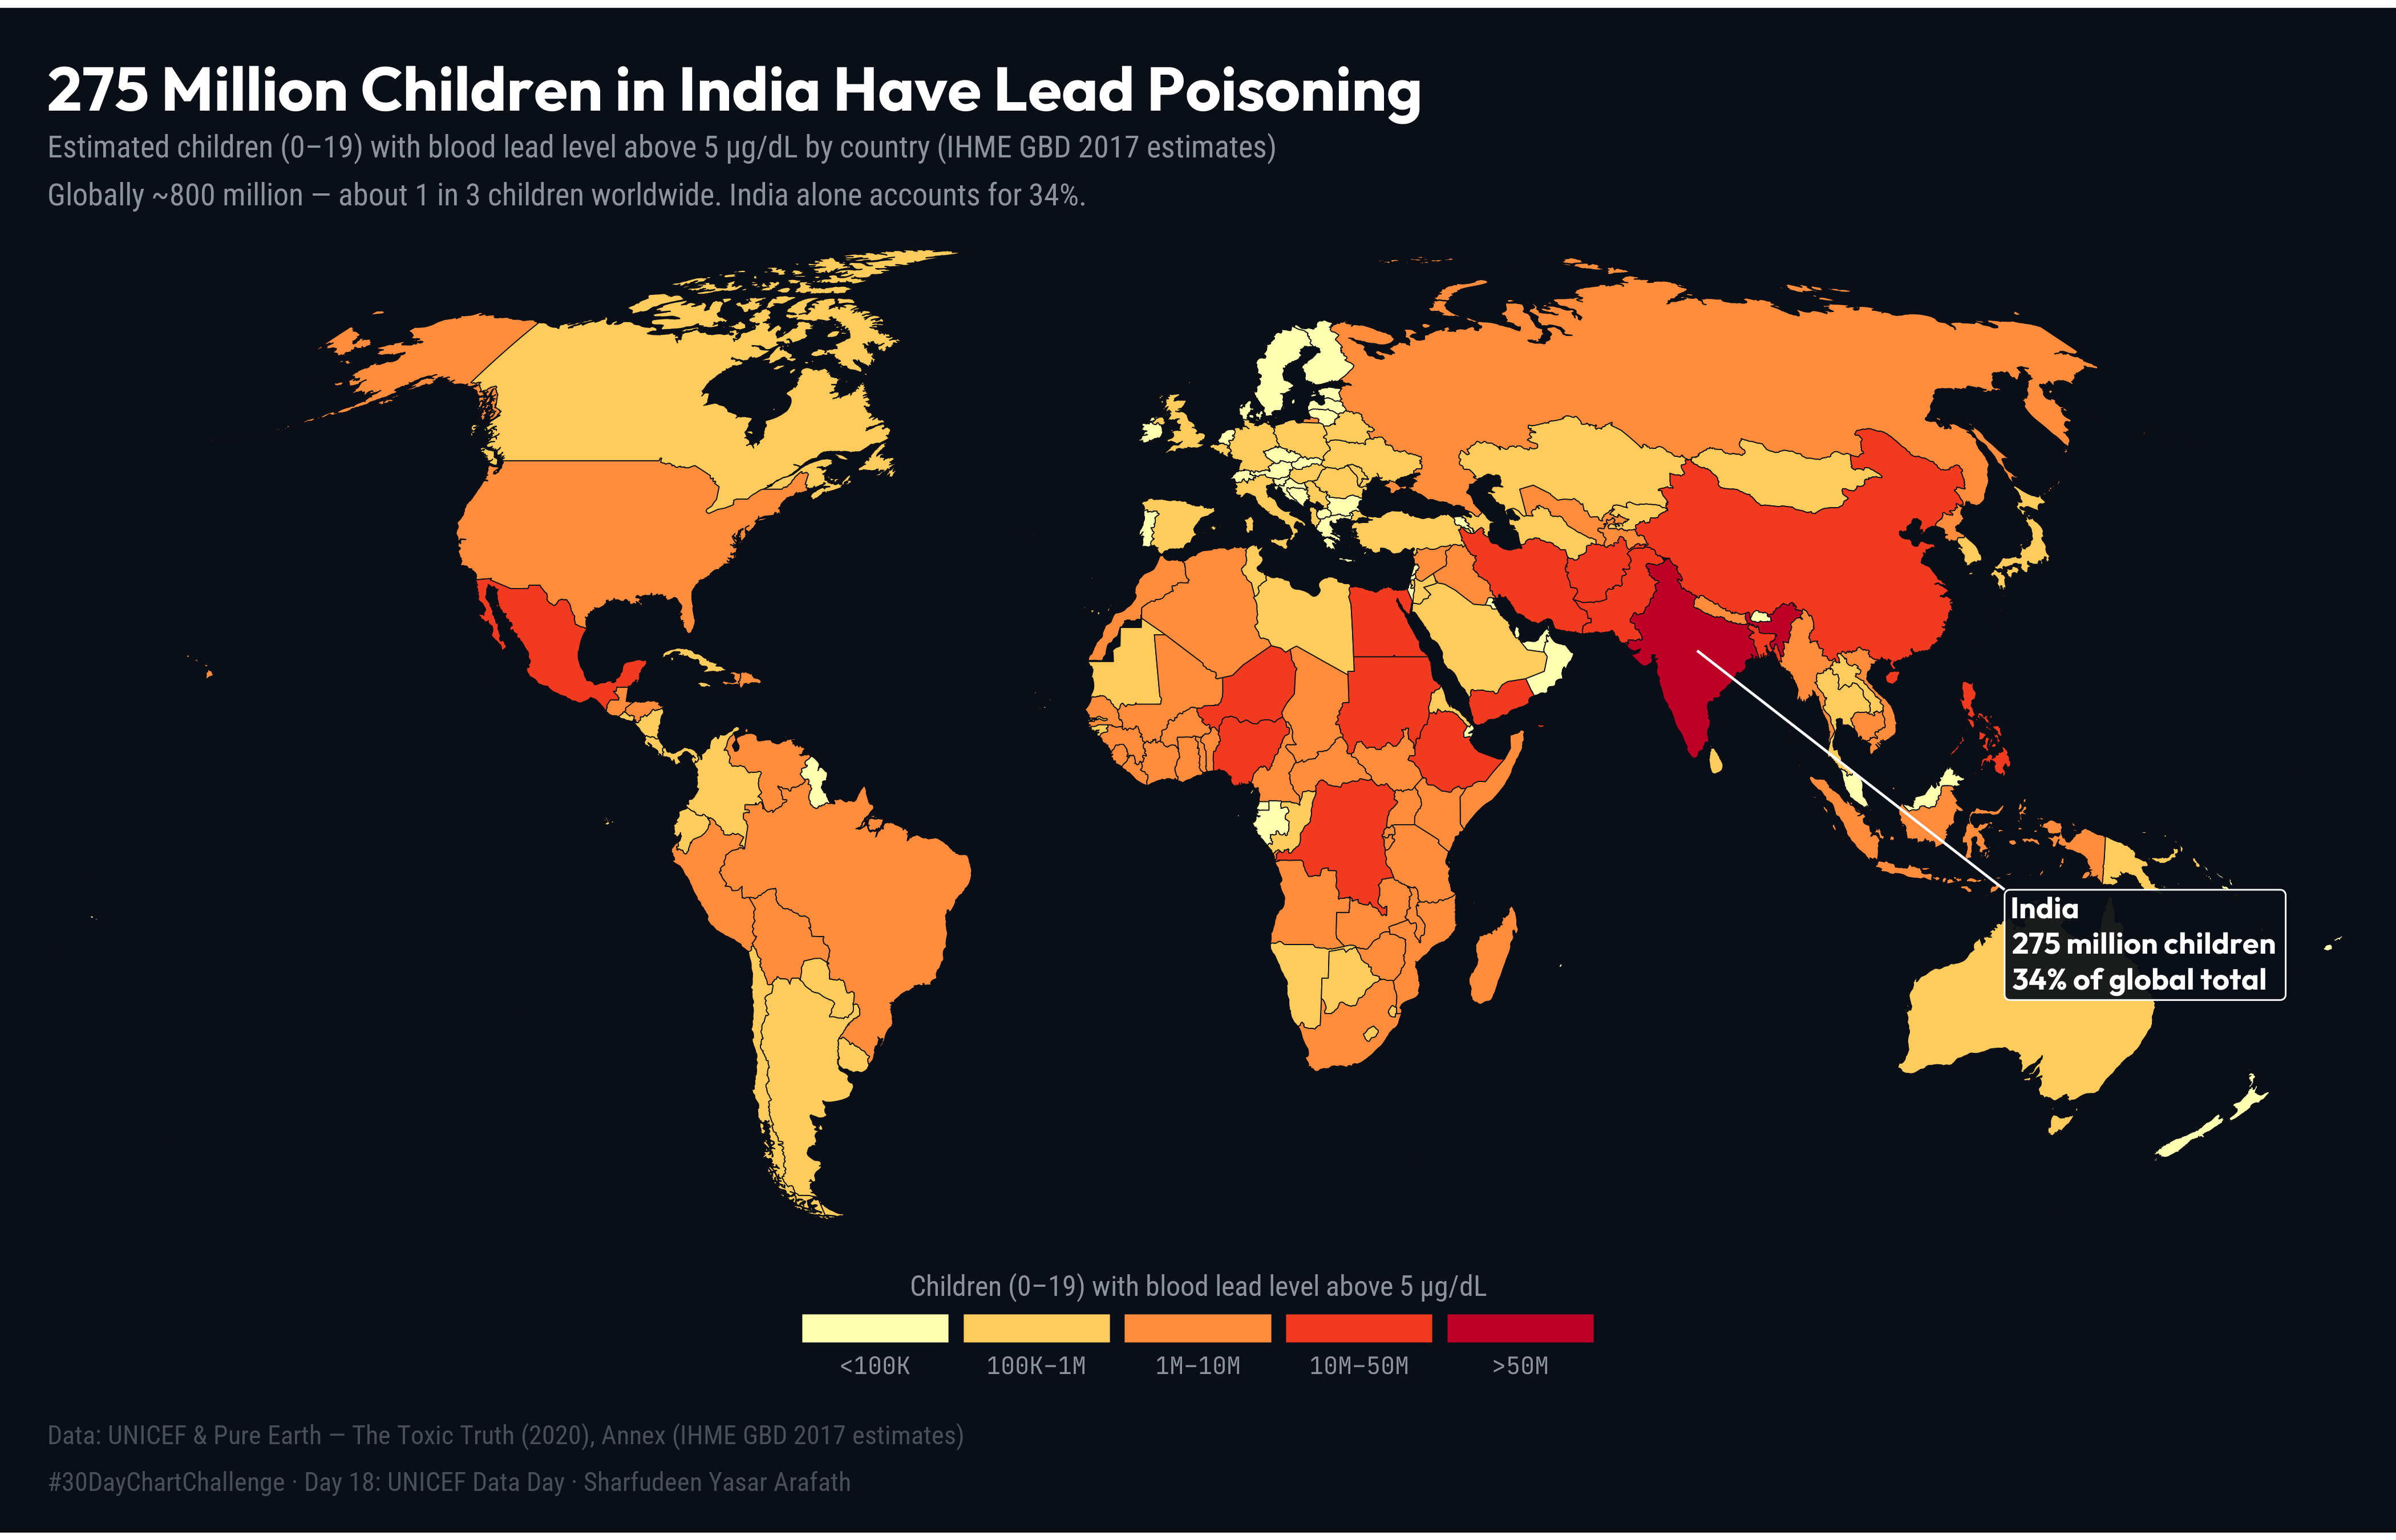

In [5]:
# — build the map -------------------------------------------------------------

library(sf)
library(RColorBrewer)

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"; txt_cap <- "#484F58"

# YlOrRd 5-step palette — strong contrast between adjacent bins
pal <- brewer.pal(5, "YlOrRd")

# India centroid for callout pointer (Robinson-projected coordinates)
india_centroid <- map_df %>%
  filter(country == "India") %>%
  st_transform("+proj=robin") %>%
  st_centroid() %>%
  st_geometry()
india_xy <- as.numeric(india_centroid[[1]])

m <- ggplot(map_df) +
  geom_sf(aes(fill = bin), color = "#0a0e17", linewidth = 0.15) +
  scale_fill_manual(
    values = pal,
    na.value = "#1a2030",
    na.translate = FALSE,
    name = "Children (0\u201319) with blood lead level above 5 \u00b5g/dL",
    drop = FALSE,
    guide = guide_legend(
      nrow = 1, title.position = "top", title.hjust = 0.5,
      keywidth = unit(2.2, "cm"), keyheight = unit(0.45, "cm"),
      label.position = "bottom")) +

  # Leader line + label callout pointing to India
  annotate("segment",
    x = india_xy[1], xend = india_xy[1] + 4.5e6,
    y = india_xy[2], yend = india_xy[2] - 3.5e6,
    color = "#FFFFFF", linewidth = 0.4) +
  annotate("label",
    x = india_xy[1] + 4.5e6, y = india_xy[2] - 3.5e6,
    label = "India\n275 million children\n34% of global total",
    family = "outfit", fontface = "bold", size = 4.4,
    color = "#FFFFFF", fill = "#0a0e17EE", label.size = 0,
    lineheight = 1.0, hjust = 0, vjust = 1) +

  coord_sf(crs = "+proj=robin", expand = FALSE) +

  labs(
    title = "275 Million Children in India Have Lead Poisoning",
    subtitle = paste0(
      "Estimated children (0\u201319) with blood lead level above 5 \u00b5g/dL by country (IHME GBD 2017 estimates)\n",
      "Globally ~800 million \u2014 about 1 in 3 children worldwide. India alone accounts for 34%."
    ),
    caption = paste0(
      "Data: UNICEF & Pure Earth \u2014 The Toxic Truth (2020), Annex (IHME GBD 2017 estimates)\n",
      "#30DayChartChallenge \u00b7 Day 18: UNICEF Data Day \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_void(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 26,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 13, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 15)),
    plot.caption = element_text(size = 11, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 15)),
    legend.position = "bottom",
    legend.title = element_text(size = 12, color = txt_dim,
      family = "roboto_condensed", margin = margin(b = 6)),
    legend.text = element_text(size = 10, color = txt_dim,
      family = "jetbrains"),
    legend.margin = margin(t = 8, b = 5),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 20, 15, 20)
  )

options(repr.plot.width = 14, repr.plot.height = 9, repr.plot.res = 300)
m

In [6]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_18_unicef.png",
       plot = m, width = 14, height = 9, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_18_unicef.png\n")

Done — saved to chart/day_18_unicef.png
